<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/Amaliy%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Ma’lumotlarni tensorlarga o‘tkazish va normalizatsiya
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST ma’lumotlar to‘plamini yuklab olish
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"Ma'lumotlar yuklandi. Jami batchlar soni: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]

Ma'lumotlar yuklandi. Jami batchlar soni: 938


In [3]:
# 2. Model arxitekturasi
model = nn.Sequential(
    nn.Flatten(),               # 28x28 tasvirni 784 o'lchamli vektorga aylantiradi
    nn.Linear(784, 128),        # Kiruvchi qatlam -> Yashirin qatlam
    nn.ReLU(),                  # Aktivatsiya funksiyasi
    nn.Linear(128, 10)          # Yashirin qatlam -> Chiquvchi qatlam (10 ta raqam)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
# 3. Loss funksiyasi va Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Epoch [1/5], O‘rtacha yo‘qotish: 0.7483
Epoch [2/5], O‘rtacha yo‘qotish: 0.3658
Epoch [3/5], O‘rtacha yo‘qotish: 0.3206
Epoch [4/5], O‘rtacha yo‘qotish: 0.2945
Epoch [5/5], O‘rtacha yo‘qotish: 0.2742


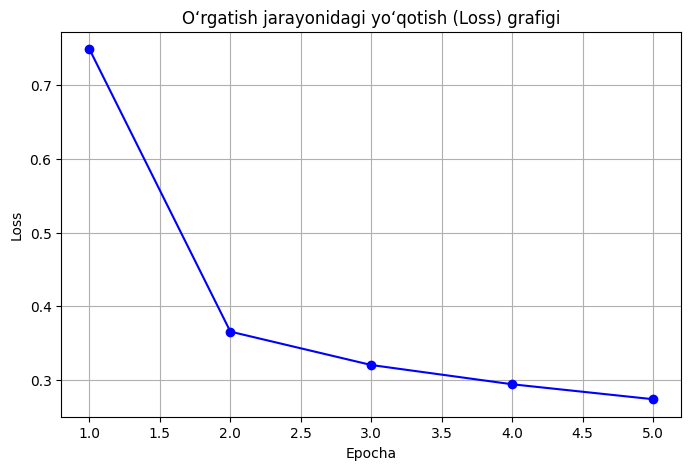

In [5]:
# 4. Modelni shug‘ullantirish
epochs = 5
loss_values = []

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # Gradiyentlarni nolga tenglashtirish
        optimizer.zero_grad()

        # Forward pass (Bashorat qilish)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass (Xatoni orqaga tarqatish)
        loss.backward()

        # Parametrlarni yangilash
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_values.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], O‘rtacha yo‘qotish: {avg_loss:.4f}")

# Yo‘qotish grafigini chizish
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_values, marker='o', color='b', linestyle='-')
plt.title('O‘rgatish jarayonidagi yo‘qotish (Loss) grafigi')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

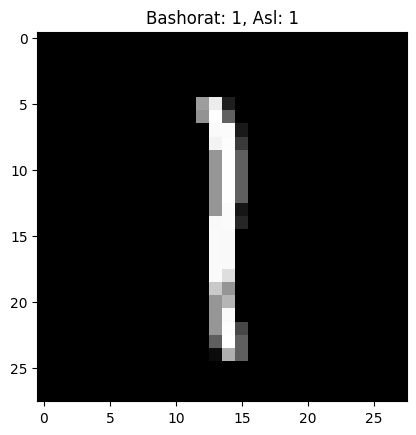

In [6]:
# Bittadan namuna olib tekshirish
dataiter = iter(train_loader)
images, labels = next(dataiter)

with torch.no_grad():
    output = model(images[0])
    prediction = torch.argmax(output).item()

plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f"Bashorat: {prediction}, Asl: {labels[0].item()}")
plt.show()